# Exercise 5

## Utils

In [ ]:
from math import exp, sqrt
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Part 1
Estimate the integral of $\int_0^1 e^x dx$ with a Monte Carlo crude estimator using 100 samples. 
Give a point estimate and confidence interval.

In [ ]:
n = 100000
 # We take the mean area under the curve y = exp(U) where U follows Uniform(0,1)
x = np.exp(np.random.uniform(size = n))
x_bar = np.sum(x) / n
s = np.std(x, ddof = 1)

alpha = 0.05
t = stats.t.ppf(1-0.05, df = n-1)
ic_inf = x_bar - t*s/sqrt(n)
ic_sup = x_bar + t*s/sqrt(n)

chi_inf = stats.chi2.ppf(1-0.05, df = n-1)
chi_sup = stats.chi2.ppf(0.05, df = n-1)
ic_var_inf = s**2 * (n-1)/chi_inf
ic_var_sup = s**2 * (n-1)/chi_sup


print("Estimated value : ", f"{x_bar:.4f}", f" with IC = [{ic_inf:.4f},{ic_sup:.4f}]")
print("Estimated variance : ", f"{s**2:.4f}", f" with IC = [{ic_var_inf:.4f},{ic_var_sup:.4f}]")
print("Theretical value : ", f"{np.exp(1) - 1:.4f}")

Estimated value :  1.7166  with IC = [1.7140,1.7192]
Estimated variance :  0.2416  with IC = [0.2398,0.2434]
Theretical value :  1.7183


## Part 2
Estimate the integral of $\int_0^1 e^x dx$ using antithetic variable and comparable computational resources.

In [ ]:
n = 100000
u = np.random.uniform(size = n)
x = 0.5*(np.exp(u)+np.exp(1-u)) # Take the average between exp(U) and exp(1-U)
x_bar = np.sum(x) / n
s = np.std(x, ddof = 1)

alpha = 0.05
t = stats.t.ppf(1-0.05, df = n-1)
ic_inf = x_bar - t*s/sqrt(n)
ic_sup = x_bar + t*s/sqrt(n)

chi_inf = stats.chi2.ppf(1-0.05, df = n-1)
chi_sup = stats.chi2.ppf(0.05, df = n-1)
ic_var_inf = s**2 * (n-1)/chi_inf
ic_var_sup = s**2 * (n-1)/chi_sup


print("Estimated value : ", f"{x_bar:.4f}", f" with IC = [{ic_inf:.4f},{ic_sup:.4f}]")
print("Estimated variance : ", f"{s**2:.4f}", f" with IC = [{ic_var_inf:.4f},{ic_var_sup:.4f}]")
print("Theretical value : ", f"{np.exp(1) - 1:.4f}")

Estimated value :  1.7179  with IC = [1.7176,1.7183]
Estimated variance :  0.0039  with IC = [0.0039,0.0039]
Theretical value :  1.7183


## Part 3
Estimate the integral of $\int_0^1 e^x dx$ using control variate and comparable computational resources.

In [ ]:
n = 100000
u = np.random.uniform(size = n)
x = np.exp(u)
y = x -(12*np.cov(x,u)[0,1])*(u-0.5)
y_bar = np.sum(y) / n
s = np.std(y, ddof = 1)

alpha = 0.05
t = stats.t.ppf(1-0.05, df = n-1)
ic_inf = y_bar - t*s/sqrt(n)
ic_sup = y_bar + t*s/sqrt(n)

chi_inf = stats.chi2.ppf(1-0.05, df = n-1)
chi_sup = stats.chi2.ppf(0.05, df = n-1)
ic_var_inf = s**2 * (n-1)/chi_inf
ic_var_sup = s**2 * (n-1)/chi_sup


print("Estimated value : ", f"{y_bar:.4f}", f" with IC = [{ic_inf:.4f},{ic_sup:.4f}]")
print("Estimated variance : ", f"{s**2:.4f}", f" with IC = [{ic_var_inf:.4f},{ic_var_sup:.4f}]")
print("Theretical value : ", f"{np.exp(1) - 1:.4f}")

Estimated value :  1.7184  with IC = [1.7181,1.7187]
Estimated variance :  0.0039  with IC = [0.0039,0.0040]
Theretical value :  1.7183


## Part 4
Estimate the integral of $\int_0^1 e^x dx$ using stratified sampling and comparable computational resources.

In [ ]:
n=100000
d = 10
x = np.exp(np.random.uniform(low =0,high = 1/d,size=n))
for j in range(1,d):
    x += np.exp(np.random.uniform(low = j/d, high = (j+1)/d, size = n))
x = x / d
x_bar = np.sum(x)/n 
s = np.std(x, ddof = 1)

alpha = 0.05

t = stats.t.ppf(1-0.05, df = n-1)
ic_inf = x_bar - t*s/sqrt(n)
ic_sup = x_bar + t*s/sqrt(n)

chi_inf = stats.chi2.ppf(1-0.05, df = n-1)
chi_sup = stats.chi2.ppf(0.05, df = n-1)
ic_var_inf = s**2 * (n-1)/chi_inf
ic_var_sup = s**2 * (n-1)/chi_sup


print("Estimated value : ", f"{x_bar:.4f}", f" with IC = [{ic_inf:.4f},{ic_sup:.4f}]")
print("Estimated variance : ", f"{s**2:.4f}", f" with IC = [{ic_var_inf:.4f},{ic_var_sup:.4f}]")
print("Theretical value : ", f"{np.exp(1) - 1:.4f}")



Estimated value :  1.7182  with IC = [1.7181,1.7183]
Estimated variance :  0.0003  with IC = [0.0003,0.0003]
Theretical value :  1.7183


## Part 5
Use control variate to reduce the variance in Exercise 4 (Poisson arrivals)

### Functions from Exercise 4 :

In [ ]:
def simulate_blocking_1_bis(la, s, m, c, display=False, seed = 0):
    np.random.seed(seed)
    t = 0
    total_customers = 0 # total number of customers who went through
    Units_waiting_time = np.zeros(m) # > 0 if busy else free
    Blocked_customers = [] 
    Arrivals = []
    next_inter_arrival_time = 0
    while total_customers < c*m : # As long as all the customers are not processed
        div = 1000
        if int(t/div) != int((t+next_inter_arrival_time)/div):
            if display:
                print(f"time : {t}, customers left : {c*m - total_customers}, busy units : {np.sum(Units_waiting_time>0)}")
            #print(Units_waiting_time)
        # time update
        t = t + next_inter_arrival_time
        Arrivals.append(next_inter_arrival_time)
        Units_waiting_time -= next_inter_arrival_time
        # arrival of a new customer
        next_inter_arrival_time = np.random.exponential(1/la)

        # attribution of the customers to potential free units
        B = 1
        i = 0
        while i < m and B == 1:
            if Units_waiting_time[i] <= 0 : # if unit nb i is free we attribute it a new customer
                #print(f'update unit {i}')
                Units_waiting_time[i] = np.random.exponential(s)
                B = 0
            i+=1
        total_customers += 1
        Blocked_customers.append(B)

    return np.array(Blocked_customers), np.array(Arrivals)

### Variance reduction using control variate

We said in class that $B_i = f(S_1, S_2, S_3, ..., A_1, A_2, A_3, ...)$ where $S_i$ is the time to process the i-th non blocked client, and A_i is the inter-arrival time between client i-1 and client i. We defined the $A_i$ and $S_i$ following the following exponential laws : $\epsilon (\lambda)$ and $\epsilon(1/s)$.  
We know from lecture 3 that exponential random variables can be simulated using uniform variables and the transformation :  
                                 $u \mapsto -log(u)/ \lambda$.

Let's try to reduce variance using the individual inter arrival times $A_i$  as the control variables.

In [ ]:
lamb = 1
s = 8
m =10
c = 10000
def sample_estimator(N,la = lamb,c = 10000, m=10):
    B_bar = []
    A_bar = []
    for i in range(N):
        B,A = simulate_blocking_1_bis(la, s, m, c, seed = i,display=False)
        #print(np.mean(B))
        B_bar.append(np.mean(B[c//10:]))
        A_bar.append(np.mean(A[c//10:]))
        if i%(N//10) == 0 :
            print(f"{(i/N)*100} %")
    return B_bar, A_bar

In [114]:
N = 20
B_bar, A_bar = sample_estimator(N)

0.0 %


10.0 %
20.0 %
30.0 %
40.0 %
50.0 %
60.0 %
70.0 %
80.0 %
90.0 %


In [115]:
B_bar = np.array(B_bar)
#print(B_bar)
A_bar = np.array(A_bar)
coef = - m*c*np.cov(B_bar,A_bar)[0,1] / (1/lamb)
Y = B_bar + coef*(A_bar - 1/lamb)

print("Estimated value : ", f"{np.mean(Y):.6f}")
print("Estimated variance : ", f"{np.var(Y):.6e}")
print("Oringinal variance : ", f"{np.var(B_bar):.6e}")
print(f"Variance reduction : {(100 - 100*np.var(Y)/np.var(B_bar)):.6f} %")

Estimated value :  0.121480
Estimated variance :  1.094401e-06
Oringinal variance :  1.983906e-06
Variance reduction : 44.836018 %


In [116]:
alpha = 0.05  # For a 95% confidence interval
ddl = N - 1   # Degrees of freedom (19)

# Estimations without control variate
mean_B_bar = np.mean(B_bar)
std_B_bar = np.std(B_bar, ddof=1) 

t_quantile = stats.t.ppf(1 - alpha / 2, df=ddl)

margin_of_error_B = t_quantile * (std_B_bar / np.sqrt(N))
ci_mean_B = (mean_B_bar - margin_of_error_B, mean_B_bar + margin_of_error_B)

print(f"1. Global Mean of B_bar (B_bar_bar): {mean_B_bar:.6f}")
print(f"   -> CI: [{ci_mean_B[0]:.6f} ; {ci_mean_B[1]:.6f}]")
print(f"   -> Interval Width: {ci_mean_B[1] - ci_mean_B[0]:.6f}\n")

var_B_bar = np.var(B_bar, ddof=1)

# Chi-squared distribution quantiles
chi2_lower = stats.chi2.ppf(alpha / 2, df=ddl)      
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=ddl)  

ci_var_B = (ddl * var_B_bar / chi2_upper, ddl * var_B_bar / chi2_lower)

print(f"2. Variance of B_bar: {var_B_bar:.6e}")
print(f"   -> CI: [{ci_var_B[0]:.6f} ; {ci_var_B[1]:.6f}]\n")

1. Global Mean of B_bar (B_bar_bar): 0.121493
   -> CI: [0.120817 ; 0.122169]
   -> Interval Width: 0.001353

2. Variance of B_bar: 2.088322e-06
   -> CI: [0.000001 ; 0.000004]



In [117]:
mean_Y = np.mean(Y)
std_Y = np.std(Y, ddof=1)

margin_of_error_Y = t_quantile * (std_Y / np.sqrt(N))
ci_mean_Y = (mean_Y - margin_of_error_Y, mean_Y + margin_of_error_Y)

print(f"3. Global Mean of Y (Control Variate): {mean_Y:.6f}")
print(f"   -> CI: [{ci_mean_Y[0]:.6f} ; {ci_mean_Y[1]:.6f}]")
print(f"   -> Interval Width: {ci_mean_Y[1] - ci_mean_Y[0]:.6f}")

var_Y = np.var(Y, ddof=1)

print(f"   -> Precision Gain (width reduction): {((ci_mean_B[1]-ci_mean_B[0]) / (ci_mean_Y[1]-ci_mean_Y[0]) - 1)*100:.1f}%\n")
print(f"variance reduction : {100*(var_B_bar-var_Y)/var_B_bar} %")

ci_var_Y = (ddl * var_Y / (chi2_upper), ddl * var_Y / (chi2_lower))

print(f"4. Variance of the estimator Y_bar: {var_Y:.6e}")
print(f"   -> CI: [{ci_var_Y[0]:.6e} ; {ci_var_Y[1]:.6e}]")

3. Global Mean of Y (Control Variate): 0.121480
   -> CI: [0.120978 ; 0.121983]
   -> Interval Width: 0.001005
   -> Precision Gain (width reduction): 34.6%

variance reduction : 44.83601849517027 %
4. Variance of the estimator Y_bar: 1.152001e-06
   -> CI: [6.662550e-07 ; 2.457530e-06]


## Part 6 -> Not seen this year

## Part 7 

### Estimate $P(Z>a)$ using crude MC estimator

In [118]:
a = 2
N = 100000

def estimated_sf(a,N):
    Z = np.random.normal(size = N)
    return np.mean(Z>a), np.var(Z>a)

#def std_MC(a,N,n):
#    return np.std([estimated_sf(a,N) for _ in range(n)])

e,v = estimated_sf(a,N)
print(f"estimated_sf({a},100000) : ", e)
print("Var from crude Monte Carlo method : ", v)
print(f"true sf({a}) : ", stats.norm.sf(a))

estimated_sf(2,100000) :  0.02193
Var from crude Monte Carlo method :  0.021449075099999996
true sf(2) :  0.022750131948179198


### Importance sampling

In [119]:
sigma = 1

def theta(x,a = a, sigma = 1):
    if x <= a:
        return 0
    else : 
        return stats.norm.pdf(x) / stats.norm.pdf(x,loc = a,scale = sigma)

N = 100000

for a in [2,4]:
    Y = []
    for i in range(N):
        x = np.random.normal(loc = a, scale = sigma)
        Y.append(theta(x,a,sigma))
    Y_bar = np.mean(Y)
    var = np.var(Y)
    v = estimated_sf(a,N)[1]
    print(f"estimator : {Y_bar} for a = {a}")
    print(f"true sf({a}) : ", stats.norm.sf(a))
    print(f"variance : {var} for a = {a}")
    print(f"MC variance {v:.4f}")
    print(f"MC variance reduction : {(100 - 100*var/v):.4f} % for N = {N} \n")


a = 2
for N in [1000,10000,100000]:
    Y = []
    for i in range(N):
        x = np.random.normal(loc = a, scale = sigma)
        Y.append(theta(x,a,sigma))
    Y_bar = np.mean(Y)
    var = np.var(Y)
    v = estimated_sf(a,N)[1]
    print(f"estimator : {Y_bar} for N = {N}")
    print(f"true sf({a}) : ", stats.norm.sf(a))
    print(f"variance : {var} for N = {N}")
    print(f"MC variance {v:.4f}")
    print(f"MC variance reduction : {(100 - 100*var/v):.4f} % for N = {N} \n")

estimator : 0.022666837546288537 for a = 2
true sf(2) :  0.022750131948179198
variance : 0.0011972956280985752 for a = 2
MC variance 0.0226
MC variance reduction : 94.7011 % for N = 100000 

estimator : 3.138793940262726e-05 for a = 4
true sf(4) :  3.167124183311986e-05
variance : 4.489881869347973e-09 for a = 4
MC variance 0.0001
MC variance reduction : 99.9925 % for N = 100000 

estimator : 0.02288136150550328 for N = 1000
true sf(2) :  0.022750131948179198
variance : 0.0012351582104295096 for N = 1000
MC variance 0.0177
MC variance reduction : 93.0122 % for N = 1000 

estimator : 0.02294591206300742 for N = 10000
true sf(2) :  0.022750131948179198
variance : 0.0012182699604833137 for N = 10000
MC variance 0.0228
MC variance reduction : 94.6466 % for N = 10000 

estimator : 0.02270065585498534 for N = 100000
true sf(2) :  0.022750131948179198
variance : 0.0012076971363299473 for N = 100000
MC variance 0.0220
MC variance reduction : 94.4994 % for N = 100000 



## Part 8

In [124]:
def theta(x,l): # h(x)*f(x)/g(x)
    if x > 1: # f(x) : make sure it is in [0,1]
        return 0
    elif x < 0 :
        return 0
    else :
        return (1/l)*np.exp((1+l)*x)
    
N = 100000
l = 1 # We indeed observe a lower variance for l = 1.3
Y = []
for i in range(N):
    x = np.random.exponential(1/l)
    Y.append(theta(x,l))
Y_bar = np.mean(Y)
var = np.var(Y)

# CI on Y_bar (Student)
t_q = stats.t.ppf(1 - alpha/2, df=ddl)
margin = t_q * sqrt(var / n)
ci_mean = (Y_bar - margin, Y_bar + margin)

# CI on variance (Chi-2)
chi2_lower = stats.chi2.ppf(alpha/2, df=ddl)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df=ddl)
ci_var = (ddl * var / chi2_upper, ddl * var / chi2_lower)



print(f"Estimator Y_bar  : {Y_bar:.6f}")
print(f"CI on Y_bar (95%): [{ci_mean[0]:.6f} ; {ci_mean[1]:.6f}] \n")
print(f"Variance         : {var:.6f}")
print(f"CI on var  (95%) : [{ci_var[0]:.6f} ; {ci_var[1]:.6f}] \n")


Estimator Y_bar  : 1.724954
CI on Y_bar (95%): [1.712688 ; 1.737220] 

Variance         : 3.434508
CI on var  (95%) : [1.986333 ; 7.326732] 



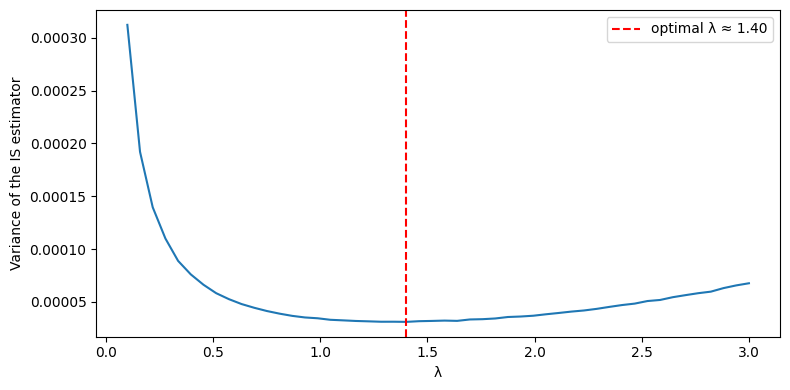

Optimal λ : 1.303  (variance = 3.116704e-05)


In [130]:
lambdas = np.linspace(0.1, 3, 50)
variances = []
for l in lambdas:
    Y = [theta(np.random.exponential(1/l), l) for _ in range(N)]
    variances.append(np.var(Y, ddof=1) / N)  # Var of the estimator Y_bar = Var(Y)/N

plt.figure(figsize=(8, 4))
plt.plot(lambdas, variances)
plt.axvline(lambdas[np.argmin(variances)], color='r', linestyle='--',
            label=f'optimal λ ≈ {lambdas[np.argmin(variances)]:.2f}')
plt.xlabel('λ')
plt.ylabel('Variance of the IS estimator')
# plt.title('Variance of the estimator $\\bar{Y}$ vs λ')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal λ : {1.303}  (variance = {min(variances):.6e})")

## Part 9

the first moment distribution is $x \mapsto \frac{xf(x)}{\mu}$ with $\mu$ the mean for a the Pareto distribution. Thus with $h(x) = x$ and $f(x) = \mathscr{1}(x \in [0,1])$ we have $\frac{f(x)h(x)}{g(x)} = \mu$. 
This shows that in general, the best sampling distribution to estimate $\mathbb{E}(h(X))$ is $g^* = \frac {f(x)h(x)}{\mathbb{E}(h(X))}$. The choice of $g$ in Part 8 cannot be improved because it would mean having access to the true value of